In [ ]:
# Quick wandb setup for Colab
# This will prompt you to paste your API key once per Colab session.
!pip install -q wandb
!wandb login


## 1-4. Setup, training, and core model checkpoints

This section trains the original and retrained models, then runs GA unlearning for the core checkpoint outputs. Redundant runtime/overall-bar figures are intentionally removed to keep outputs focused.

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import time
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Subset, DataLoader
import warnings
import os

try:
    import wandb
except ImportError:
    wandb = None  # optional: install with pip install wandb

warnings.filterwarnings("ignore", category=DeprecationWarning)

# CIFAR-10 and experiment config
NUM_CLASSES = 10
OUT_DIR = "out"
resnet_model_depth = 50

# GPU perf defaults (safe no-ops on CPU)
if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.set_float32_matmul_precision("high")

# A100/Ampere-friendly mixed precision defaults
ENABLE_AMP = torch.cuda.is_available()
USE_BF16 = ENABLE_AMP and torch.cuda.get_device_capability(0)[0] >= 8
AMP_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
ENABLE_GRAD_SCALER = ENABLE_AMP and (AMP_DTYPE == torch.float16)

@torch.inference_mode()
def evaluate(net, loader, num_classes=NUM_CLASSES, device="cpu"):
    net.eval()
    correct = 0
    total = 0
    correct_c = torch.zeros(num_classes, device=device)
    total_c = torch.zeros(num_classes, device=device)

    amp_enabled = (device.type == "cuda")

    for inputs, labels in loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=amp_enabled):
            outputs = net(inputs)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.numel()

        for c in range(num_classes):
            mask = (labels == c)
            total_c[c] += mask.sum()
            correct_c[c] += (preds[mask] == labels[mask]).sum()

    overall_acc = correct / total if total > 0 else 0.0
    per_class_acc = (correct_c / torch.clamp(total_c, min=1)).detach().cpu().numpy()

    net.train()
    return overall_acc, per_class_acc


class Net(nn.Module):
    """
    ResNet adapted for CIFAR-10 (32x32) by using a 3x3 stride-1 conv
    and removing the initial maxpool. Architecture controlled by model_depth (18, 34, or 50).
    """
    def __init__(self, num_classes=NUM_CLASSES, pretrained=False, model_depth=50):
        super().__init__()

        from torchvision.models import resnet18, resnet34, resnet50
        from torchvision.models import ResNet18_Weights, ResNet34_Weights, ResNet50_Weights

        # Map model_depth to architecture function and weights class
        resnet_map = {
            18: (resnet18, ResNet18_Weights),
            34: (resnet34, ResNet34_Weights),
            50: (resnet50, ResNet50_Weights),
        }

        if model_depth not in resnet_map:
            raise ValueError(f"model_depth must be one of {list(resnet_map.keys())}, got {model_depth}")

        resnet_fn, weights_class = resnet_map[model_depth]

        if pretrained:
            base = resnet_fn(weights=weights_class.DEFAULT)
        else:
            base = resnet_fn(weights=None)

        if not pretrained:
            base.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
            base.maxpool = nn.Identity()

        base.fc = nn.Linear(base.fc.in_features, num_classes)
        self.model = base

    def forward(self, x):
        return self.model(x)


def make_loader(dataset, batch_size, shuffle, num_workers, use_cuda):
    kwargs = {
        "batch_size": batch_size,
        "shuffle": shuffle,
        "num_workers": num_workers,
        "pin_memory": use_cuda,
    }
    if num_workers > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 4
    return DataLoader(dataset, **kwargs)


def train_model(net, trainloader, testloader, num_epochs, device, lr=0.01, momentum=0.9,
                weight_decay=1e-4, save_path=None, log_prefix="", lr_milestones=None, lr_gamma=0.1,
                wandb_prefix=None, wandb_step_offset=0):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
    scheduler = None
    if lr_milestones is not None:
        scheduler = optim.lr_scheduler.MultiStepLR(optimizer, milestones=lr_milestones, gamma=lr_gamma)

    amp_enabled = (device.type == "cuda")
    scaler = torch.cuda.amp.GradScaler(enabled=(amp_enabled and ENABLE_GRAD_SCALER))

    acc_history = []
    time_history = []

    for epoch in range(num_epochs):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.perf_counter()

        epoch_loss = 0.0
        for inputs, labels in trainloader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=amp_enabled):
                outputs = net(inputs)
                loss = criterion(outputs, labels)

            if amp_enabled:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                optimizer.step()

            epoch_loss += loss.item()

        if scheduler is not None:
            scheduler.step()

        acc, _ = evaluate(net, testloader, num_classes=NUM_CLASSES, device=device)
        acc_history.append(acc)

        if device.type == "cuda":
            torch.cuda.synchronize()
        dt = time.perf_counter() - t0
        time_history.append(dt)

        mean_loss = epoch_loss / len(trainloader)
        current_lr = optimizer.param_groups[0]["lr"]
        if wandb and wandb_prefix is not None:
            wandb.log({
                f"{wandb_prefix}/train_loss": mean_loss,
                f"{wandb_prefix}/test_acc": acc,
                f"{wandb_prefix}/lr": current_lr,
                f"{wandb_prefix}/epoch_time_s": dt,
            }, step=wandb_step_offset + epoch)

        print(f"{log_prefix}epoch {epoch+1}/{num_epochs} loss {mean_loss:.3f} "
              f"test_acc {acc:.3f} lr {current_lr:.2e} epoch_s {dt:.2f}")

    if save_path is not None:
        torch.save(net.state_dict(), save_path)
        print(f"Saved to {save_path}")

    return acc_history, time_history


def main():
    num_epochs = 20
    batch_size = 50
    target_label = 6  # class 6 to exclude (frog)
    # Smaller LR for unlearning to reduce collateral damage to non-target classes.
    unlearn_lr = 3e-5
    unlearn_epochs = 10

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    transform = transforms.Compose( 
        [
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    )

    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
    testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

    use_cuda = (device.type == "cuda")
    num_workers = min(12, os.cpu_count() or 2) if use_cuda else 2
    trainloader = make_loader(trainset, batch_size, True, num_workers, use_cuda)
    testloader = make_loader(testset, batch_size, False, num_workers, use_cuda)

    os.makedirs(OUT_DIR, exist_ok=True)

    if wandb is not None:
        wandb.init(project="gradient-ascent", config={
            "num_epochs": num_epochs,
            "batch_size": batch_size,
            "target_label": target_label,
            "unlearn_lr": unlearn_lr,
            "unlearn_epochs": unlearn_epochs,
            "weight_decay": 1e-4,
            "model_depth": resnet_model_depth,
        })

    # -----------------------
    # 1) Original model train
    # -----------------------
    original_net = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
    original_acc_history, original_time_history = train_model(
        original_net,
        trainloader,
        testloader,
        num_epochs=num_epochs,
        device=device,
        lr=0.01,
        momentum=0.9,
        weight_decay=1e-4,
        save_path=f"{OUT_DIR}/original_net.pt",
        log_prefix="original ",
        wandb_prefix="original",
        wandb_step_offset=0,
    )

    # ---------------------------------------------------------
    # 2) Retrain from scratch on data excluding class == 6
    # ---------------------------------------------------------
    keep_indices = [idx for idx, lbl in enumerate(trainset.targets) if lbl != target_label]
    keep_subset = Subset(trainset, keep_indices)
    keep_loader = make_loader(keep_subset, batch_size, True, num_workers, use_cuda)

    retrain_net = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
    retrain_acc_history, retrain_time_history = train_model(
        retrain_net,
        keep_loader,
        testloader,
        num_epochs=num_epochs,
        device=device,
        lr=0.01,
        momentum=0.9,
        weight_decay=1e-4,
        save_path=f"{OUT_DIR}/retrained_from_scratch_net.pt",
        log_prefix="retrain ",
        wandb_prefix="retrain",
        wandb_step_offset=num_epochs,
    )

    plt.figure()
    plt.plot(range(1, num_epochs + 1), original_acc_history, label="Original (all data)", color="tab:blue")
    plt.plot(range(1, num_epochs + 1), retrain_acc_history, label="Retrained from scratch", color="tab:orange")
    plt.xlabel("Epoch")
    plt.ylabel("Test accuracy")
    plt.title(f"Original and retrained-from-scratch test accuracy vs epoch (ResNet-{resnet_model_depth})")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"{OUT_DIR}/original_vs_retrain_acc.png")
    print("Saved plot to out/original_vs_retrain_acc.png")
    if wandb is not None:
        wandb.log({"plots/original_vs_retrain": wandb.Image(plt.gcf())})

    # --------------------------------------------
    # 3) Unlearning snapshots for GA / SSD / SalUn
    # --------------------------------------------
    amp_enabled = (device.type == "cuda")
    criterion = nn.CrossEntropyLoss()

    forget_indices = [idx for idx, lbl in enumerate(trainset.targets) if lbl == target_label]
    retain_indices = [idx for idx, lbl in enumerate(trainset.targets) if lbl != target_label]
    forget_subset = Subset(trainset, forget_indices)
    retain_subset = Subset(trainset, retain_indices)

    # Use dedicated unlearning loader settings (decoupled from training batch size)
    # to avoid overly aggressive per-epoch updates.
    unlearn_batch_size = 512 if USE_BF16 else 256
    ga_max_batches_per_epoch = 10
    salun_max_batches_per_epoch = 8

    forget_loader = make_loader(forget_subset, unlearn_batch_size, True, num_workers, use_cuda)
    retain_loader = make_loader(retain_subset, unlearn_batch_size, True, num_workers, use_cuda)

    # Shared classwise plotting helper (used after all snapshots are ready).
    cifar10_classes = [
        "airplane", "automobile", "bird", "cat", "deer",
        "dog", "frog", "horse", "ship", "truck",
    ]
    algo_display = {"ga": "GA", "ssd": "SSD", "salun": "SalUn"}

    classwise_epochs = {"ga": [], "ssd": [], "salun": []}
    classwise_histories = {"ga": [], "ssd": [], "salun": []}
    classwise_algo_offset = {"ga": 0, "ssd": 100, "salun": 200}
    classwise_step_base = 3 * num_epochs + unlearn_epochs

    def add_classwise_point(algorithm_key, epoch_num, per_class):
        classwise_epochs[algorithm_key].append(int(epoch_num))
        arr = np.asarray(per_class, dtype=np.float32)
        classwise_histories[algorithm_key].append(arr)
        if wandb is not None and wandb.run is not None:
            step = int(classwise_step_base + classwise_algo_offset[algorithm_key] + epoch_num)
            for cls_idx, acc in enumerate(arr):
                wandb.log({f"classwise/{algorithm_key}/class_{cls_idx}_acc": float(acc)}, step=step)

    def save_classwise_plot_from_history(algorithm_key):
        history = np.stack(classwise_histories[algorithm_key], axis=0)
        initial_acc = history[0]
        denom = np.where(initial_acc == 0, 1e-12, initial_acc)
        percent_change = 100.0 * (history - initial_acc) / denom

        fig = plt.figure(figsize=(10, 6))
        for cls in range(NUM_CLASSES):
            plt.plot(classwise_epochs[algorithm_key], percent_change[:, cls], label=cifar10_classes[cls])

        label = algo_display.get(algorithm_key, algorithm_key)
        plt.xlabel("Unlearning Epoch")
        plt.ylabel("Accuracy Change (%)")
        plt.title(f"Relative Change in Class Accuracy During Unlearning ({label}, ResNet-{resnet_model_depth})")
        plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
        plt.legend(loc="lower left", fontsize="small", ncol=2)
        plt.tight_layout()

        out_path = f"{OUT_DIR}/classwise_percent_change_{algorithm_key}.png"
        fig.savefig(out_path, dpi=180)
        plt.show()
        plt.close(fig)
        print(f"Saved plot to {out_path}")

        # Absolute class accuracy plot (raw, not normalized to epoch 0)
        fig_abs = plt.figure(figsize=(10, 6))
        for cls in range(NUM_CLASSES):
            plt.plot(classwise_epochs[algorithm_key], 100.0 * history[:, cls], label=cifar10_classes[cls])

        plt.xlabel("Unlearning Epoch")
        plt.ylabel("Class Accuracy (%)")
        plt.title(f"Absolute Class Accuracy During Unlearning ({label}, ResNet-{resnet_model_depth})")
        plt.ylim(0, 100)
        plt.legend(loc="lower left", fontsize="small", ncol=2)
        plt.tight_layout()

        abs_out_path = f"{OUT_DIR}/classwise_absolute_accuracy_{algorithm_key}.png"
        fig_abs.savefig(abs_out_path, dpi=180)
        plt.show()
        plt.close(fig_abs)
        print(f"Saved plot to {abs_out_path}")

        if wandb is not None and wandb.run is not None:
            wandb.log({f"plots/classwise_percent_change_{algorithm_key}": wandb.Image(out_path)})
            wandb.log({f"plots/classwise_absolute_accuracy_{algorithm_key}": wandb.Image(abs_out_path)})

    # ---- GA snapshots ----
    print(f"Unlearning (GA) on class {target_label} with lr={unlearn_lr:.2e}")
    ga_dir = f"{OUT_DIR}/unlearning_snapshots_ga"
    os.makedirs(ga_dir, exist_ok=True)

    ga_model = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
    ga_model.load_state_dict(torch.load(f"{OUT_DIR}/original_net.pt", map_location=device))
    ga_optimizer = optim.SGD(ga_model.parameters(), lr=unlearn_lr, momentum=0.0)
    ga_scaler = torch.cuda.amp.GradScaler(enabled=(amp_enabled and ENABLE_GRAD_SCALER))

    torch.save(ga_model.state_dict(), f"{ga_dir}/epoch_000.pt")
    _ga_acc0, ga_per0 = evaluate(ga_model, testloader, num_classes=NUM_CLASSES, device=device)
    add_classwise_point("ga", 0, ga_per0)

    for epoch in range(1, unlearn_epochs + 1):
        t0 = time.perf_counter()
        ga_model.train()
        epoch_loss = 0.0
        ga_steps = 0
        for batch_idx, (inputs, labels) in enumerate(forget_loader):
            if ga_max_batches_per_epoch is not None and batch_idx >= ga_max_batches_per_epoch:
                break
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            ga_optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=amp_enabled):
                outputs = ga_model(inputs)
                loss = criterion(outputs, labels)
            if amp_enabled:
                ga_scaler.scale(-loss).backward()
                ga_scaler.step(ga_optimizer)
                ga_scaler.update()
            else:
                (-loss).backward()
                ga_optimizer.step()
            epoch_loss += loss.item()
            ga_steps += 1

        ga_mean_loss = epoch_loss / max(1, ga_steps)
        total_acc, per_class = evaluate(ga_model, testloader, num_classes=NUM_CLASSES, device=device)
        add_classwise_point("ga", epoch, per_class)
        dt = time.perf_counter() - t0
        print(f"[GA epoch {epoch}] loss {ga_mean_loss:.3f} total_acc {total_acc:.3f} epoch_s {dt:.2f}")
        if wandb is not None and wandb.run is not None:
            wandb.log({
                "unlearn_ga/train_loss": ga_mean_loss,
                "unlearn_ga/test_acc": total_acc,
                f"unlearn_ga/class_{target_label}_acc": float(per_class[target_label]),
                "unlearn_ga/epoch_time_s": dt,
            }, step=2 * num_epochs + epoch)

        torch.save(ga_model.state_dict(), f"{ga_dir}/epoch_{epoch:03d}.pt")

    torch.save(ga_model.state_dict(), f"{OUT_DIR}/unlearned_net.pt")
    torch.save(ga_model.state_dict(), f"{OUT_DIR}/unlearned_net_ga.pt")
    print("Saved GA models to out/unlearned_net.pt and out/unlearned_net_ga.pt")

    # ---- SSD snapshots ----
    # Gentler SSD preset to reduce collateral retained-class degradation.
    ssd_unlearn_epochs = 4
    ssd_alpha = 1.75
    ssd_lambda = 0.05
    ssd_eps = 1e-8
    ssd_min_scale = 0.2
    ssd_fisher_batches = 8

    def estimate_empirical_fisher_diag(model, loader, max_batches):
        params_named = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
        fisher = {n: torch.zeros_like(p, device=device) for n, p in params_named}

        model.eval()
        n_batches = 0
        for i, (inputs, labels) in enumerate(loader):
            if i >= max_batches:
                break
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            model.zero_grad(set_to_none=True)
            logits = model(inputs)
            loss = criterion(logits, labels)
            grads = torch.autograd.grad(loss, [p for _, p in params_named], retain_graph=False, create_graph=False)
            for (name, _), g in zip(params_named, grads):
                fisher[name] += g.detach() ** 2
            n_batches += 1

        if n_batches == 0:
            raise RuntimeError("No batches processed for Fisher estimation.")
        for name in fisher:
            fisher[name] /= float(n_batches)
        return fisher

    ssd_dir = f"{OUT_DIR}/unlearning_snapshots_ssd"
    os.makedirs(ssd_dir, exist_ok=True)
    ssd_model = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
    ssd_model.load_state_dict(torch.load(f"{OUT_DIR}/original_net.pt", map_location=device))

    max_fisher_batches = min(ssd_fisher_batches, len(forget_loader), len(retain_loader))
    print(f"Estimating SSD Fisher with {max_fisher_batches} batches...")
    fisher_forget = estimate_empirical_fisher_diag(ssd_model, forget_loader, max_fisher_batches)
    fisher_retain = estimate_empirical_fisher_diag(ssd_model, retain_loader, max_fisher_batches)

    torch.save(ssd_model.state_dict(), f"{ssd_dir}/epoch_000.pt")
    _ssd_acc0, ssd_per0 = evaluate(ssd_model, testloader, num_classes=NUM_CLASSES, device=device)
    add_classwise_point("ssd", 0, ssd_per0)

    step_lambda = ssd_lambda / float(ssd_unlearn_epochs)
    for epoch in range(1, ssd_unlearn_epochs + 1):
        with torch.no_grad():
            for name, p in ssd_model.named_parameters():
                if not p.requires_grad:
                    continue
                ratio = fisher_forget[name] / (fisher_retain[name] + ssd_eps)
                damp = 1.0 - step_lambda * torch.relu(ratio - ssd_alpha)
                damp = torch.clamp(damp, min=ssd_min_scale, max=1.0)
                p.mul_(damp)

        _ssd_acc, ssd_per = evaluate(ssd_model, testloader, num_classes=NUM_CLASSES, device=device)
        add_classwise_point("ssd", epoch, ssd_per)
        torch.save(ssd_model.state_dict(), f"{ssd_dir}/epoch_{epoch:03d}.pt")

    torch.save(ssd_model.state_dict(), f"{OUT_DIR}/unlearned_net_ssd.pt")
    print("Saved SSD model to out/unlearned_net_ssd.pt")

    # ---- SalUn snapshots ----
    # Gentler SalUn preset to preserve retained-class accuracy.
    salun_lr = 1e-5
    salun_mask_ratio = 0.05
    salun_mask_batches = 8

    def estimate_salun_importance(model, loader, max_batches):
        params_named = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
        importance = {n: torch.zeros_like(p, device=device) for n, p in params_named}

        model.train()
        n_batches = 0
        for i, (inputs, labels) in enumerate(loader):
            if i >= max_batches:
                break
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            model.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=amp_enabled):
                logits = model(inputs)
                loss = criterion(logits, labels)
            grads = torch.autograd.grad(loss, [p for _, p in params_named], retain_graph=False, create_graph=False)
            for (name, _), g in zip(params_named, grads):
                importance[name] += g.detach().abs()
            n_batches += 1

        if n_batches == 0:
            raise RuntimeError("No batches processed for SalUn mask estimation.")
        for name in importance:
            importance[name] /= float(n_batches)
        return importance

    def build_salun_mask(importance, mask_ratio):
        flat_scores = torch.cat([v.reshape(-1) for v in importance.values()])
        k = max(1, int(mask_ratio * flat_scores.numel()))
        threshold = torch.topk(flat_scores, k=k, largest=True).values[-1]
        return {name: (vals >= threshold).to(vals.dtype) for name, vals in importance.items()}

    salun_dir = f"{OUT_DIR}/unlearning_snapshots_salun"
    os.makedirs(salun_dir, exist_ok=True)
    salun_model = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
    salun_model.load_state_dict(torch.load(f"{OUT_DIR}/original_net.pt", map_location=device))

    max_mask_batches = min(salun_mask_batches, len(forget_loader))
    print(f"Estimating SalUn mask with {max_mask_batches} forget batches...")
    salun_importance = estimate_salun_importance(salun_model, forget_loader, max_mask_batches)
    salun_mask = build_salun_mask(salun_importance, salun_mask_ratio)

    salun_optimizer = optim.SGD(salun_model.parameters(), lr=salun_lr, momentum=0.0)
    salun_scaler = torch.cuda.amp.GradScaler(enabled=(amp_enabled and ENABLE_GRAD_SCALER))

    torch.save(salun_model.state_dict(), f"{salun_dir}/epoch_000.pt")
    _salun_acc0, salun_per0 = evaluate(salun_model, testloader, num_classes=NUM_CLASSES, device=device)
    add_classwise_point("salun", 0, salun_per0)

    for epoch in range(1, unlearn_epochs + 1):
        salun_model.train()
        for batch_idx, (inputs, labels) in enumerate(forget_loader):
            if salun_max_batches_per_epoch is not None and batch_idx >= salun_max_batches_per_epoch:
                break
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            salun_optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=amp_enabled):
                outputs = salun_model(inputs)
                loss = criterion(outputs, labels)

            if amp_enabled:
                salun_scaler.scale(-loss).backward()
                salun_scaler.unscale_(salun_optimizer)
            else:
                (-loss).backward()

            for name, p in salun_model.named_parameters():
                if p.grad is None or name not in salun_mask:
                    continue
                p.grad.mul_(salun_mask[name])

            if amp_enabled:
                salun_scaler.step(salun_optimizer)
                salun_scaler.update()
            else:
                salun_optimizer.step()

        _salun_acc, salun_per = evaluate(salun_model, testloader, num_classes=NUM_CLASSES, device=device)
        add_classwise_point("salun", epoch, salun_per)
        torch.save(salun_model.state_dict(), f"{salun_dir}/epoch_{epoch:03d}.pt")

    torch.save(salun_model.state_dict(), f"{OUT_DIR}/unlearned_net_salun.pt")
    print("Saved SalUn model to out/unlearned_net_salun.pt")

    # ---------------------------------------------------------
    # 4) Classwise figures (GA / SSD / SalUn) from in-loop epoch logs
    # ---------------------------------------------------------
    for algo_key in ["ga", "ssd", "salun"]:
        print(f"Computing classwise trajectory plot for {algo_key.upper()}...")
        save_classwise_plot_from_history(algo_key)

    # ---------------------------------------------------------
    # 5) Similarity trajectories and animations are intentionally
    #    computed in the later similarity sections.
    # ---------------------------------------------------------
    # ---------------------------------------------------------
    # 6) Quick comparison of class-6 accuracy at end (GA final)
    # ---------------------------------------------------------
    original_overall, original_per = evaluate(original_net, testloader, device=device)
    retrain_overall, retrain_per = evaluate(retrain_net, testloader, device=device)
    ga_overall, ga_per = evaluate(ga_model, testloader, device=device)

    print(f"overall test acc original:   {original_overall:.3f}")
    print(f"overall test acc retrained:  {retrain_overall:.3f}")
    print(f"overall test acc unlearned (GA):   {ga_overall:.3f}")

    print(f"class 6 test acc original:   {original_per[target_label]:.3f}")
    print(f"class 6 test acc retrained:  {retrain_per[target_label]:.3f}")
    print(f"class 6 test acc unlearned (GA):   {ga_per[target_label]:.3f}")

    if wandb is not None and wandb.run is not None:
        wandb.log({
            "summary/original_overall_acc": original_overall,
            "summary/retrain_overall_acc": retrain_overall,
            "summary/unlearned_ga_overall_acc": ga_overall,
            "summary/class6_original_acc": float(original_per[target_label]),
            "summary/class6_retrain_acc": float(retrain_per[target_label]),
            "summary/class6_unlearned_ga_acc": float(ga_per[target_label]),
        })

    print("Main pipeline complete: training, GA/SSD/SalUn snapshots, and classwise figures generated.")

hello


In [ ]:
main()


100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s] 


baseline epoch 1/10 loss 2.086 test_acc 0.315 epoch_s 9.58
baseline epoch 2/10 loss 1.791 test_acc 0.373 epoch_s 7.70
baseline epoch 3/10 loss 1.643 test_acc 0.414 epoch_s 7.29
baseline epoch 4/10 loss 1.548 test_acc 0.440 epoch_s 6.93
baseline epoch 5/10 loss 1.473 test_acc 0.459 epoch_s 7.57
baseline epoch 6/10 loss 1.407 test_acc 0.476 epoch_s 7.06
baseline epoch 7/10 loss 1.348 test_acc 0.494 epoch_s 7.13
baseline epoch 8/10 loss 1.296 test_acc 0.513 epoch_s 7.17
baseline epoch 9/10 loss 1.246 test_acc 0.531 epoch_s 7.08
baseline epoch 10/10 loss 1.198 test_acc 0.541 epoch_s 6.94
Saved to out/baseline_net.pt
Saved plot to out/acc_vs_epoch.png
excl6 epoch 1/10 loss 2.053 test_acc 0.274 epoch_s 6.88
excl6 epoch 2/10 loss 1.754 test_acc 0.349 epoch_s 6.56
excl6 epoch 3/10 loss 1.575 test_acc 0.390 epoch_s 7.23
excl6 epoch 4/10 loss 1.467 test_acc 0.409 epoch_s 6.46
excl6 epoch 5/10 loss 1.393 test_acc 0.430 epoch_s 6.68
excl6 epoch 6/10 loss 1.334 test_acc 0.440 epoch_s 6.87
excl6 epo

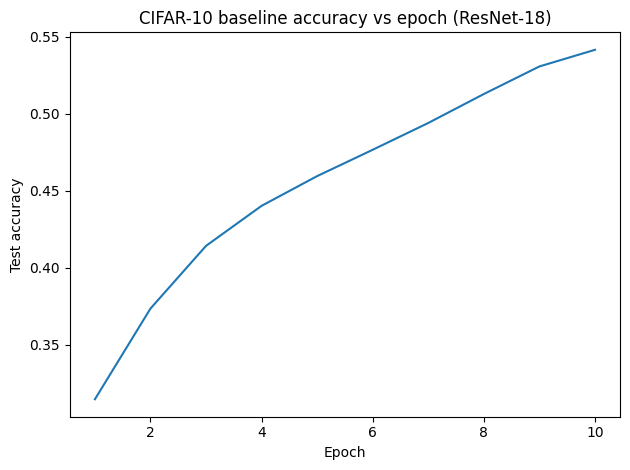

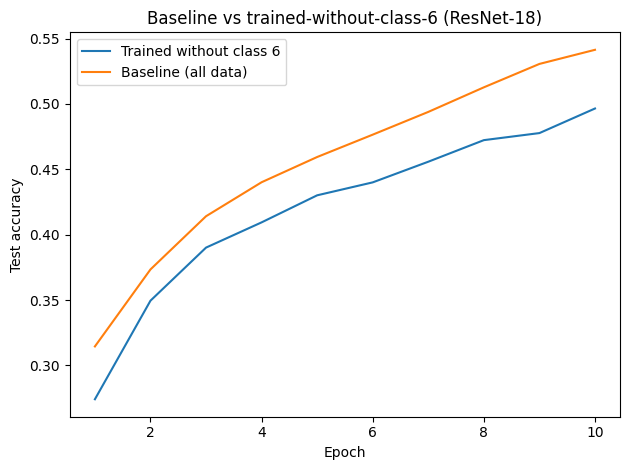

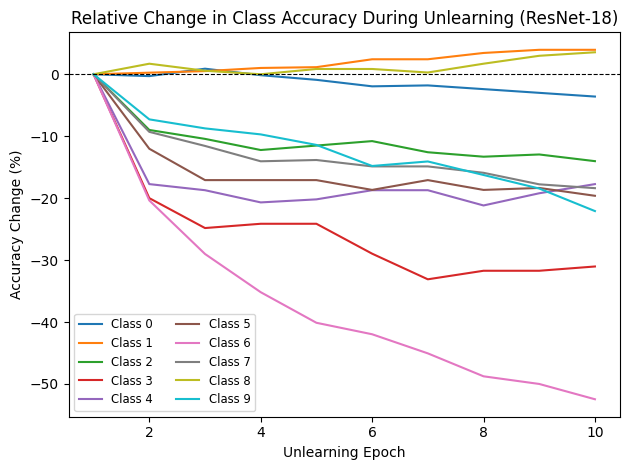

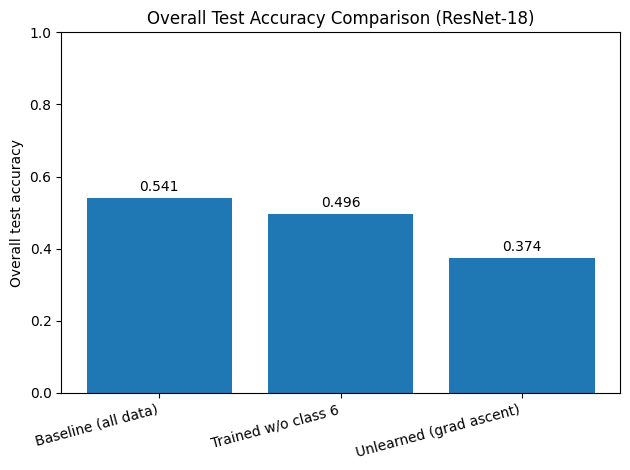

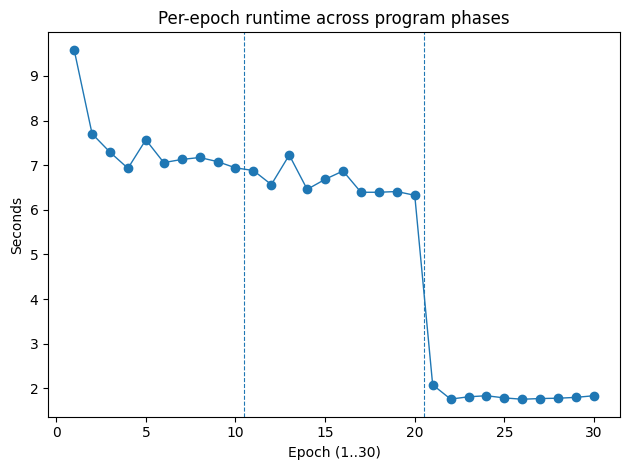

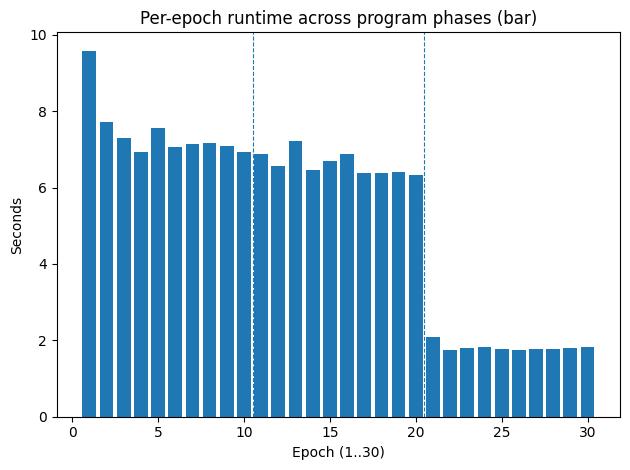

In [ ]:
# Colab dependency for Gromov-Wasserstein metric (ot module)
!pip install -q pot

In [ ]:
# Similarity Definitions
# Source copied from scripts/similarity.py for Colab-friendly execution.

import torch
import numpy as np
from scipy.linalg import svd
from typing import Union, Optional
import scipy.stats
import ot  # POT: Python Optimal Transport
from scipy.spatial.distance import cdist


class CCA:
    """
    Canonical Correlation Analysis (CCA) for comparing neural network representations.
    Implementation based on the paper "Similarity of Neural Network Representations Revisited"
    """

    def __init__(self, epsilon: float = 1e-8):
        """
        Initialize CCA calculator.

        Args:
            epsilon: Small constant for numerical stability
        """
        self.epsilon = epsilon

    def _center_data(self, X: np.ndarray) -> np.ndarray:
        """Center the data by removing the mean."""
        return X - X.mean(axis=0, keepdims=True)

    def compute_similarity(
        self,
        X: Union[np.ndarray, torch.Tensor],
        Y: Union[np.ndarray, torch.Tensor],
        return_correlations: bool = False,
    ) -> Union[float, tuple]:
        """
        Compute CCA similarity between two representation matrices.

        Args:
            X: First representation matrix (n_samples, n_features_1)
            Y: Second representation matrix (n_samples, n_features_2)
            return_correlations: If True, return individual correlations as well

        Returns:
            float or tuple: CCA similarity score, and optionally the canonical correlations
        """
        if isinstance(X, torch.Tensor):
            X = X.detach().cpu().numpy()
        if isinstance(Y, torch.Tensor):
            Y = Y.detach().cpu().numpy()

        if X.ndim > 2:
            X = X.reshape(X.shape[0], -1)
        if Y.ndim > 2:
            Y = Y.reshape(Y.shape[0], -1)

        X = self._center_data(X)
        Y = self._center_data(Y)

        Qx, _Rx = np.linalg.qr(X)
        Qy, _Ry = np.linalg.qr(Y)

        try:
            cross_cov = Qx.T @ Qy
            _U, correlations, _Vh = svd(cross_cov)
            correlations = np.clip(correlations, 0, 1)

            K = min(X.shape[1], Y.shape[1])
            correlations = correlations[:K]

            mean_correlation = np.mean(correlations)
        except np.linalg.LinAlgError:
            print("Warning: SVD computation failed, returning zeros")
            K = min(X.shape[1], Y.shape[1])
            correlations = np.zeros(K)
            mean_correlation = 0.0

        if return_correlations:
            return mean_correlation, correlations
        return mean_correlation


class CKA:
    """
    Centered Kernel Alignment (CKA) for comparing neural network representations.
    Implementation based on "Similarity of Neural Network Representations Revisited"
    """

    def __init__(self, kernel: str = "linear"):
        """
        Initialize CKA calculator.

        Args:
            kernel: Type of kernel to use ('linear' or 'rbf')
        """
        self.kernel = kernel

    def _center_gram(self, K: np.ndarray) -> np.ndarray:
        """Center the Gram matrix."""
        means = K.mean(axis=0, keepdims=True)
        means_T = means.T
        global_mean = means.mean()
        return K - means - means_T + global_mean

    def _linear_kernel(self, X: np.ndarray) -> np.ndarray:
        """Compute the linear kernel."""
        return X @ X.T

    def _rbf_kernel(self, X: np.ndarray, sigma: Optional[float] = None) -> np.ndarray:
        """Compute the RBF (Gaussian) kernel using vectorized operations."""
        n_samples = X.shape[0]

        if sigma is None:
            max_subset = min(1000, n_samples)
            rng = np.random.RandomState(42)
            subset_idx = rng.choice(n_samples, size=max_subset, replace=False)
            X_subset = X[subset_idx]

            X_subset_squared = np.sum(X_subset**2, axis=1, keepdims=True)
            subset_sq_dists = X_subset_squared + X_subset_squared.T - 2 * X_subset @ X_subset.T
            subset_sq_dists = np.maximum(subset_sq_dists, 0)
            sigma = np.median(subset_sq_dists[subset_sq_dists > 0])
            if sigma == 0:
                sigma = 1.0

        X_squared_norms = np.sum(X**2, axis=1, keepdims=True)
        sq_dists = X_squared_norms + X_squared_norms.T - 2 * X @ X.T
        sq_dists = np.maximum(sq_dists, 0)
        K = np.exp(-sq_dists / (2 * sigma))
        return K

    def compute_similarity(
        self,
        X: Union[np.ndarray, torch.Tensor],
        Y: Union[np.ndarray, torch.Tensor],
    ) -> float:
        """
        Compute CKA similarity between two representation matrices.
        """
        if isinstance(X, torch.Tensor):
            X = X.detach().cpu().numpy()
        if isinstance(Y, torch.Tensor):
            Y = Y.detach().cpu().numpy()

        if X.ndim > 2:
            X = X.reshape(X.shape[0], -1)
        if Y.ndim > 2:
            Y = Y.reshape(Y.shape[0], -1)

        if self.kernel == "linear":
            K = self._linear_kernel(X)
            L = self._linear_kernel(Y)
        else:
            K = self._rbf_kernel(X)
            L = self._rbf_kernel(Y)

        K = self._center_gram(K)
        L = self._center_gram(L)

        hsic = np.sum(K * L)
        normalization = np.sqrt(np.sum(K * K) * np.sum(L * L))

        if normalization > 0:
            cka = hsic / normalization
        else:
            cka = 0.0

        return cka


class EuclideanDistance:
    """
    Euclidean Distance calculator for comparing neural network representations.
    Lower values indicate more similar representations.
    """

    def compute_similarity(
        self,
        X: Union[np.ndarray, torch.Tensor],
        Y: Union[np.ndarray, torch.Tensor],
    ) -> float:
        """
        Compute average Euclidean distance between two representation matrices.
        """
        if isinstance(X, torch.Tensor):
            X = X.detach().cpu().numpy()
        if isinstance(Y, torch.Tensor):
            Y = Y.detach().cpu().numpy()

        if X.ndim == 1:
            X = X.reshape(1, -1)
        if Y.ndim == 1:
            Y = Y.reshape(1, -1)

        if X.ndim > 2:
            X = X.reshape(X.shape[0], -1)
        if Y.ndim > 2:
            Y = Y.reshape(Y.shape[0], -1)

        if X.shape[1] != Y.shape[1]:
            raise ValueError("X and Y must have the same number of features")

        X_norm = np.linalg.norm(X, axis=1, keepdims=True)
        Y_norm = np.linalg.norm(Y, axis=1, keepdims=True)
        X_normalized = X / (X_norm + 1e-8)
        Y_normalized = Y / (Y_norm + 1e-8)

        distances = np.linalg.norm(X_normalized - Y_normalized, axis=1)
        return float(np.mean(distances))


class CosineSimilarity:
    """
    Cosine Similarity calculator for comparing neural network representations.
    Values closer to 1 indicate more similar representations.
    """

    def compute_similarity(
        self,
        X: Union[np.ndarray, torch.Tensor],
        Y: Union[np.ndarray, torch.Tensor],
    ) -> float:
        """
        Compute average cosine similarity between two representation matrices.
        """
        if isinstance(X, torch.Tensor):
            X = X.detach().cpu().numpy()
        if isinstance(Y, torch.Tensor):
            Y = Y.detach().cpu().numpy()

        if X.ndim == 1:
            X = X.reshape(1, -1)
        if Y.ndim == 1:
            Y = Y.reshape(1, -1)

        if X.ndim > 2:
            X = X.reshape(X.shape[0], -1)
        if Y.ndim > 2:
            Y = Y.reshape(Y.shape[0], -1)

        if X.shape[1] != Y.shape[1]:
            raise ValueError("X and Y must have the same number of features")

        X_norm = np.linalg.norm(X, axis=1, keepdims=True)
        Y_norm = np.linalg.norm(Y, axis=1, keepdims=True)

        X_normalized = X / (X_norm + 1e-8)
        Y_normalized = Y / (Y_norm + 1e-8)

        similarities = np.sum(X_normalized * Y_normalized, axis=1)
        return float(np.mean(similarities))


class EarthMoversDistance:
    """
    Earth Mover's Distance (Wasserstein distance) for comparing neural network representations.
    Lower values indicate more similar representations.
    """

    def compute_similarity(
        self,
        X: Union[np.ndarray, torch.Tensor],
        Y: Union[np.ndarray, torch.Tensor],
    ) -> float:
        """
        Compute average EMD (Wasserstein distance) between two representation matrices.
        """
        if isinstance(X, torch.Tensor):
            X = X.detach().cpu().numpy()
        if isinstance(Y, torch.Tensor):
            Y = Y.detach().cpu().numpy()

        if X.ndim > 2:
            X = X.reshape(X.shape[0], -1)
        if Y.ndim > 2:
            Y = Y.reshape(Y.shape[0], -1)

        if X.shape[1] != Y.shape[1]:
            raise ValueError("X and Y must have the same number of features")

        emd_per_feature = [
            scipy.stats.wasserstein_distance(X[:, i], Y[:, i])
            for i in range(X.shape[1])
        ]
        return float(np.mean(emd_per_feature))


class GromovWassersteinDistance:
    """
    Computes the (entropic-regularised) squared Gromov-Wasserstein distance
    between two point clouds, then converts it to a similarity score.
    """

    def __init__(
        self,
        intra_metric: str = "cosine",
        loss_fun: str = "square_loss",
        reg: float = 5e-4,
        max_iter: int = 30,
        tol: float = 1e-9,
        to_similarity=lambda d: 1.0 / (1.0 + d),
    ):
        self.intra_metric = intra_metric
        self.loss_fun = loss_fun
        self.reg = reg
        self.max_iter = max_iter
        self.tol = tol
        self._to_sim = to_similarity

    def _cost_matrices(self, X, Y):
        Cx = cdist(X, X, metric=self.intra_metric).astype(np.float64)
        Cy = cdist(Y, Y, metric=self.intra_metric).astype(np.float64)
        Cx /= np.median(Cx)
        Cy /= np.median(Cy)
        return Cx, Cy

    def compute_similarity(self, X: np.ndarray, Y: np.ndarray) -> float:
        Cx, Cy = self._cost_matrices(X, Y)
        p = np.ones(Cx.shape[0]) / Cx.shape[0]
        q = np.ones(Cy.shape[0]) / Cy.shape[0]

        gw_dist = ot.gromov.gromov_wasserstein2(
            Cx,
            Cy,
            p,
            q,
            loss_fun=self.loss_fun,
            epsilon=self.reg,
            max_iter=self.max_iter,
            tol=self.tol,
            verbose=False,
            log=False,
        )
        return self._to_sim(gw_dist)


class KLDivergence:
    """
    Kullback-Leibler Divergence for comparing neural network representations.
    Treats representations as probability distributions and measures their divergence.
    Lower values indicate more similar representations.
    """

    def __init__(self, epsilon: float = 1e-8, symmetric: bool = True):
        """
        Initialize KL divergence calculator.
        """
        self.epsilon = epsilon
        self.symmetric = symmetric

    def _to_probability_distribution(self, X: np.ndarray) -> np.ndarray:
        """
        Convert representation matrix to probability distributions.
        Each row becomes a probability distribution over features.
        """
        X_abs = np.abs(X)
        X_stable = X_abs + self.epsilon
        X_prob = X_stable / np.sum(X_stable, axis=1, keepdims=True)
        return X_prob

    def _kl_divergence(self, P: np.ndarray, Q: np.ndarray) -> float:
        """
        Compute KL divergence between two probability distributions.
        KL(P||Q) = sum(P * log(P/Q))
        """
        Q_stable = Q + self.epsilon
        kl = np.sum(P * np.log(P / Q_stable), axis=1)
        return np.mean(kl)

    def compute_similarity(
        self,
        X: Union[np.ndarray, torch.Tensor],
        Y: Union[np.ndarray, torch.Tensor],
    ) -> float:
        """
        Compute KL divergence between two representation matrices.
        """
        if isinstance(X, torch.Tensor):
            X = X.detach().cpu().numpy()
        if isinstance(Y, torch.Tensor):
            Y = Y.detach().cpu().numpy()

        if X.ndim == 1:
            X = X.reshape(1, -1)
        if Y.ndim == 1:
            Y = Y.reshape(1, -1)

        if X.ndim > 2:
            X = X.reshape(X.shape[0], -1)
        if Y.ndim > 2:
            Y = Y.reshape(Y.shape[0], -1)

        if X.shape[1] != Y.shape[1]:
            raise ValueError("X and Y must have the same number of features")

        if X.shape[0] != Y.shape[0]:
            raise ValueError("X and Y must have the same number of samples")

        P = self._to_probability_distribution(X)
        Q = self._to_probability_distribution(Y)

        if self.symmetric:
            kl_pq = self._kl_divergence(P, Q)
            kl_qp = self._kl_divergence(Q, P)
            return 0.5 * (kl_pq + kl_qp)
        else:
            return self._kl_divergence(P, Q)

## 5. Shared similarity helpers

Defines reusable activation extraction, metric evaluation, and plotting helpers used by downstream trajectory analysis. Standalone final pairwise snapshot generation is removed to avoid redundancy.

In [ ]:
# Shared similarity helpers (used by trajectory sections)
# Standalone final pairwise snapshot generation is intentionally removed.

from collections import defaultdict

import numpy as np
import torch
import matplotlib.pyplot as plt

layer_names = [
    "model.conv1",
    "model.layer1",
    "model.layer2",
    "model.layer3",
    "model.layer4",
    "model.fc",
]

# -----------------------------------------------------------------------------
# Activation extraction (single model)
# -----------------------------------------------------------------------------
def collect_model_activations(model, loader, layers, device, max_batches=10):
    modules = dict(model.named_modules())
    missing = [ln for ln in layers if ln not in modules]
    if missing:
        raise ValueError(f"Missing layer names in model: {missing}")

    acts = defaultdict(list)
    hooks = []

    def _hook_factory(layer_name):
        def _hook(_module, _inputs, output):
            if isinstance(output, (tuple, list)):
                output = output[0]
            out = output.detach().cpu()
            if out.ndim > 2:
                out = out.mean(dim=tuple(range(2, out.ndim)))
            acts[layer_name].append(out)
        return _hook

    for ln in layers:
        hooks.append(modules[ln].register_forward_hook(_hook_factory(ln)))

    amp_enabled = (device.type == "cuda")

    with torch.no_grad():
        for i, (inputs, _labels) in enumerate(loader):
            if max_batches is not None and i >= max_batches:
                break
            inputs = inputs.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=amp_enabled):
                _ = model(inputs)

    for h in hooks:
        h.remove()

    for ln in layers:
        # Cast BF16/FP16 activations to FP32 before NumPy conversion.
        acts[ln] = torch.cat(acts[ln], dim=0).to(torch.float32).numpy()

    return acts

# -----------------------------------------------------------------------------
# Metric setup
# -----------------------------------------------------------------------------
metrics = {
    "cka_linear": CKA(kernel="linear"),
    "cca": CCA(),
    "cosine": CosineSimilarity(),
    "euclidean": EuclideanDistance(),
    "kl_sym": KLDivergence(symmetric=True),
}

higher_better_metrics = ["cka_linear", "cca", "cosine"]
lower_better_metrics = ["euclidean", "kl_sym"]
plot_metric_names = higher_better_metrics + lower_better_metrics

# -----------------------------------------------------------------------------
# Helpers
# -----------------------------------------------------------------------------
def evaluate_pair_rows(acts_a, acts_b):
    rows = []
    for layer in layer_names:
        x = acts_a[layer]
        y = acts_b[layer]
        row = {"layer": layer, "n_samples": int(x.shape[0]), "n_features": int(x.shape[1])}
        for metric_name, metric in metrics.items():
            row[metric_name] = float(metric.compute_similarity(x, y))
        rows.append(row)
    return rows


def transform_rows_for_plot(rows):
    """Normalize lower-is-better metrics to [0,1], then invert to higher-is-better."""
    transformed = [{k: v for k, v in r.items()} for r in rows]

    for metric_name in lower_better_metrics:
        vals = np.array([r[metric_name] for r in rows], dtype=np.float64)
        vmin = float(np.min(vals))
        vmax = float(np.max(vals))
        if vmax > vmin:
            norm_vals = (vals - vmin) / (vmax - vmin)
        else:
            # If all values are equal, assign neutral mid-similarity.
            norm_vals = np.full_like(vals, 0.5)
        sim_vals = 1.0 - norm_vals
        for i in range(len(transformed)):
            transformed[i][metric_name] = float(sim_vals[i])

    return transformed


def plot_grouped_bars(rows, title):
    rows_plot = transform_rows_for_plot(rows)
    plot_layers = [r["layer"] for r in rows_plot]
    layer_to_row = {r["layer"]: r for r in rows_plot}

    fig, ax = plt.subplots(1, 1, figsize=(18, 6), constrained_layout=True)

    x = np.arange(len(plot_metric_names), dtype=np.float64)
    n_layers = len(plot_layers)
    total_group_width = 0.84
    bar_width = total_group_width / n_layers
    offsets = (np.arange(n_layers) - (n_layers - 1) / 2.0) * bar_width

    for i, layer in enumerate(plot_layers):
        values = [layer_to_row[layer][m] for m in plot_metric_names]
        ax.bar(x + offsets[i], values, width=bar_width, label=layer)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_metric_names, rotation=20)
    ax.set_title(f"{title} (all metrics scaled to higher = more similar)")
    ax.set_xlabel("Metric")
    ax.set_ylabel("Similarity")
    ax.grid(axis="y", alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

    return fig

print("Shared similarity helpers loaded (no standalone final pairwise snapshots generated).")

## 6. Epoch-wise unlearning trajectories and animations

Runs GA, SSD, and SalUn snapshot trajectories and generates evolving similarity summaries and GIFs for both references: unlearned-vs-retrained and unlearned-vs-original.

In [ ]:
# Unlearning algorithm comparison trajectories (GA vs SSD vs SalUn)
# Produces animations and displays them inline in the notebook.

import os
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import display, Image as IPyImage

# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------
target_label = 6

unlearn_epochs = 10
trajectory_batch_size = 512 if USE_BF16 else 256
max_batches_for_similarity = 8

# SSD (Selective Synaptic Dampening) hyperparameters
# Paper: https://arxiv.org/abs/2308.07707
# Tuned to be less aggressive: fewer dampening steps + lower total dampening strength.
ssd_unlearn_epochs = 4
ssd_alpha = 1.75
ssd_lambda = 0.05
ssd_eps = 1e-8
ssd_min_scale = 0.2
ssd_fisher_batches = 8

# SalUn hyperparameters
# Paper: https://arxiv.org/pdf/2310.12508
salun_lr = 1e-5
salun_mask_ratio = 0.05  # gentler top-k fraction of forget-important parameters
salun_mask_batches = 8

layer_names = [
    "model.conv1",
    "model.layer1",
    "model.layer2",
    "model.layer3",
    "model.layer4",
    "model.fc",
]

higher_better_metrics = ["cka_linear", "cca", "cosine"]
lower_better_metrics = ["euclidean", "kl_sym"]
all_metrics = higher_better_metrics + lower_better_metrics


def ensure_wandb_run():
    if wandb is None:
        return None
    if wandb.run is None:
        wandb.init(project="gradient-ascent", name="unlearning-algorithm-comparison")
    return wandb.run

# -----------------------------------------------------------------------------
# Data + checkpoints
# -----------------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
amp_enabled = (device.type == "cuda")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)

use_cuda = (device.type == "cuda")
num_workers = min(12, os.cpu_count() or 2) if use_cuda else 2

testloader = make_loader(testset, trajectory_batch_size, False, num_workers, use_cuda)

forget_indices = [idx for idx, lbl in enumerate(trainset.targets) if lbl == target_label]
retain_indices = [idx for idx, lbl in enumerate(trainset.targets) if lbl != target_label]

forget_subset = Subset(trainset, forget_indices)
retain_subset = Subset(trainset, retain_indices)

forget_loader = make_loader(forget_subset, trajectory_batch_size, True, num_workers, use_cuda)
retain_loader = make_loader(retain_subset, trajectory_batch_size, True, num_workers, use_cuda)

original_path = f"{OUT_DIR}/original_net.pt"
retrain_path = f"{OUT_DIR}/retrained_from_scratch_net.pt"
for p in [original_path, retrain_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(f"Missing checkpoint: {p}")

# -----------------------------------------------------------------------------
# Shared helper checks (reuse definitions from the pairwise similarity cell)
# -----------------------------------------------------------------------------
if "collect_model_activations" not in globals() or "evaluate_pair_rows" not in globals() or "plot_grouped_bars" not in globals() or "transform_rows_for_plot" not in globals():
    raise RuntimeError("Run the pairwise similarity cell before this cell to load shared helper functions.")


def save_and_display_animation(epoch_rows, algorithm_key, reference_key):
    fig_anim, ax_anim = plt.subplots(1, 1, figsize=(18, 6), constrained_layout=True)

    def draw_frame(frame_idx):
        epoch_num, rows = epoch_rows[frame_idx]
        rows_plot = transform_rows_for_plot(rows)
        layer_to_row = {r["layer"]: r for r in rows_plot}

        ax_anim.clear()

        x = np.arange(len(all_metrics), dtype=np.float64)
        n_layers = len(layer_names)
        total_group_width = 0.84
        bar_width = total_group_width / n_layers
        offsets = (np.arange(n_layers) - (n_layers - 1) / 2.0) * bar_width

        for i, layer in enumerate(layer_names):
            vals = [layer_to_row[layer][m] for m in all_metrics]
            ax_anim.bar(x + offsets[i], vals, width=bar_width, label=layer)

        ref_label = reference_key.capitalize()
        ax_anim.set_xticks(x)
        ax_anim.set_xticklabels(all_metrics, rotation=20)
        ax_anim.set_title(f"{algorithm_key.upper()}: Unlearned_t vs {ref_label} (epoch={epoch_num})\n(all metrics scaled to higher = more similar)")
        ax_anim.set_xlabel("Metric")
        ax_anim.set_ylabel("Similarity")
        ax_anim.grid(axis="y", alpha=0.3)

        handles, labels = ax_anim.get_legend_handles_labels()
        fig_anim.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

    ani = FuncAnimation(fig_anim, draw_frame, frames=len(epoch_rows), interval=900, repeat=True)
    gif_path = f"{OUT_DIR}/similarity_vs_unlearning_epoch_{algorithm_key}_vs_{reference_key}.gif"
    ani.save(gif_path, writer=PillowWriter(fps=1))
    plt.close(fig_anim)

    print(f"Saved animation to {gif_path}")
    display(IPyImage(filename=gif_path))

    run = ensure_wandb_run()
    if run is not None:
        wandb.log({f"videos/similarity_vs_unlearning_epoch_{algorithm_key}_vs_{reference_key}": wandb.Video(gif_path, format="gif")})

    return gif_path


def save_trajectory_csv(epoch_rows, algorithm_key, reference_key):
    path = f"{OUT_DIR}/similarity_vs_unlearning_epoch_{algorithm_key}_vs_{reference_key}.csv"
    header = ["epoch", "layer", "n_samples", "n_features"] + all_metrics
    with open(path, "w", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=header)
        writer.writeheader()
        for e, rows in epoch_rows:
            for r in rows:
                writer.writerow({"epoch": e, **{k: r[k] for k in r}})
    print(f"Saved trajectory CSV to {path}")


def save_summary_plot(epoch_rows, algorithm_key, reference_key):
    epochs = [e for e, _ in epoch_rows]

    # Build raw mean-across-layer series by metric.
    series = {m: [] for m in all_metrics}
    for _epoch, rows in epoch_rows:
        for m in all_metrics:
            series[m].append(float(np.mean([r[m] for r in rows])))

    # Normalize lower-is-better metrics over epochs, then invert.
    for m in lower_better_metrics:
        vals = np.array(series[m], dtype=np.float64)
        vmin = float(np.min(vals))
        vmax = float(np.max(vals))
        if vmax > vmin:
            vals = (vals - vmin) / (vmax - vmin)
        else:
            vals = np.full_like(vals, 0.5)
        series[m] = list(1.0 - vals)

    fig, ax = plt.subplots(1, 1, figsize=(16, 5), constrained_layout=True)
    for m in all_metrics:
        ax.plot(epochs, series[m], marker="o", label=m)

    ref_label = reference_key.capitalize()
    ax.set_title(f"{algorithm_key.upper()} vs {ref_label} over unlearning epochs (all metrics scaled to higher = more similar)")
    ax.set_xlabel("Unlearning epoch")
    ax.set_ylabel("Similarity (mean across layers)")
    ax.grid(alpha=0.3)
    ax.legend(ncol=3)

    out_path = f"{OUT_DIR}/similarity_vs_unlearning_epoch_{algorithm_key}_vs_{reference_key}_summary.png"
    fig.savefig(out_path, dpi=180)
    plt.show()
    plt.close(fig)
    print(f"Saved summary plot to {out_path}")

    run = ensure_wandb_run()
    if run is not None:
        wandb.log({f"plots/similarity_vs_unlearning_epoch_{algorithm_key}_vs_{reference_key}_summary": wandb.Image(out_path)})

# -----------------------------------------------------------------------------
# Prepare fixed reference features (retrained model)
# -----------------------------------------------------------------------------
metrics = {
    "cka_linear": CKA(kernel="linear"),
    "cca": CCA(),
    "cosine": CosineSimilarity(),
    "euclidean": EuclideanDistance(),
    "kl_sym": KLDivergence(symmetric=True),
}

retrained_model = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
retrained_model.load_state_dict(torch.load(retrain_path, map_location=device))
retrained_model.eval()
retrained_acts = collect_model_activations(retrained_model, testloader, layer_names, device, max_batches=max_batches_for_similarity)

original_model_frozen = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
original_model_frozen.load_state_dict(torch.load(original_path, map_location=device))
original_model_frozen.eval()
original_acts = collect_model_activations(original_model_frozen, testloader, layer_names, device, max_batches=max_batches_for_similarity)
for p in original_model_frozen.parameters():
    p.requires_grad = False

# -----------------------------------------------------------------------------
# Algorithm training loops (save per-epoch snapshots)
# -----------------------------------------------------------------------------
def run_ga_snapshots():
    algo = "ga"
    snapshot_dir = f"{OUT_DIR}/unlearning_snapshots_{algo}"
    os.makedirs(snapshot_dir, exist_ok=True)

    model = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
    model.load_state_dict(torch.load(original_path, map_location=device))

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=3e-5, momentum=0.0)
    scaler = torch.cuda.amp.GradScaler(enabled=(amp_enabled and ENABLE_GRAD_SCALER))

    torch.save(model.state_dict(), f"{snapshot_dir}/epoch_000.pt")

    for epoch in range(1, unlearn_epochs + 1):
        model.train()
        for inputs, labels in forget_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=amp_enabled):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            if amp_enabled:
                scaler.scale(-loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                (-loss).backward()
                optimizer.step()
        torch.save(model.state_dict(), f"{snapshot_dir}/epoch_{epoch:03d}.pt")

    torch.save(model.state_dict(), f"{OUT_DIR}/unlearned_net_ga.pt")
    return snapshot_dir


def estimate_empirical_fisher_diag(model, loader, criterion, max_batches):
    """Estimate diagonal empirical Fisher via average squared gradients."""
    params_named = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
    fisher = {n: torch.zeros_like(p, device=device) for n, p in params_named}

    model.eval()
    n_batches = 0
    for i, (inputs, labels) in enumerate(loader):
        if i >= max_batches:
            break
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        model.zero_grad(set_to_none=True)
        logits = model(inputs)
        loss = criterion(logits, labels)

        grads = torch.autograd.grad(loss, [p for _, p in params_named], retain_graph=False, create_graph=False)
        for (name, _), g in zip(params_named, grads):
            fisher[name] += g.detach() ** 2

        n_batches += 1

    if n_batches == 0:
        raise RuntimeError("No batches processed for Fisher estimation.")

    for name in fisher:
        fisher[name] /= float(n_batches)
    return fisher


def run_ssd_snapshots():
    # SSD: post-hoc dampening based on relative Fisher importance to forget vs retain sets.
    algo = "ssd"
    snapshot_dir = f"{OUT_DIR}/unlearning_snapshots_{algo}"
    os.makedirs(snapshot_dir, exist_ok=True)

    model = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
    model.load_state_dict(torch.load(original_path, map_location=device))

    criterion = nn.CrossEntropyLoss()
    max_fisher_batches = min(ssd_fisher_batches, len(forget_loader), len(retain_loader))

    print(f"Estimating SSD Fisher diagonals with {max_fisher_batches} batches...")
    print(f"Running SSD dampening for {ssd_unlearn_epochs} epochs (alpha={ssd_alpha}, lambda={ssd_lambda})")
    fisher_forget = estimate_empirical_fisher_diag(model, forget_loader, criterion, max_fisher_batches)
    fisher_retain = estimate_empirical_fisher_diag(model, retain_loader, criterion, max_fisher_batches)

    # Save initial state (epoch 0)
    torch.save(model.state_dict(), f"{snapshot_dir}/epoch_000.pt")

    # Apply dampening progressively across SSD-specific epochs for trajectory visualization.
    step_lambda = ssd_lambda / float(ssd_unlearn_epochs)

    for epoch in range(1, ssd_unlearn_epochs + 1):
        with torch.no_grad():
            for name, p in model.named_parameters():
                if not p.requires_grad:
                    continue
                ratio = fisher_forget[name] / (fisher_retain[name] + ssd_eps)
                damp = 1.0 - step_lambda * torch.relu(ratio - ssd_alpha)
                damp = torch.clamp(damp, min=ssd_min_scale, max=1.0)
                p.mul_(damp)

        torch.save(model.state_dict(), f"{snapshot_dir}/epoch_{epoch:03d}.pt")

    torch.save(model.state_dict(), f"{OUT_DIR}/unlearned_net_ssd.pt")
    return snapshot_dir


def estimate_salun_importance(model, loader, criterion, max_batches):
    """Estimate SalUn forget-importance via average absolute gradients."""
    params_named = [(n, p) for n, p in model.named_parameters() if p.requires_grad]
    importance = {n: torch.zeros_like(p, device=device) for n, p in params_named}

    model.train()
    n_batches = 0
    for i, (inputs, labels) in enumerate(loader):
        if i >= max_batches:
            break

        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        model.zero_grad(set_to_none=True)
        with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=amp_enabled):
            logits = model(inputs)
            loss = criterion(logits, labels)

        grads = torch.autograd.grad(loss, [p for _, p in params_named], retain_graph=False, create_graph=False)
        for (name, _), g in zip(params_named, grads):
            importance[name] += g.detach().abs()

        n_batches += 1

    if n_batches == 0:
        raise RuntimeError("No batches processed for SalUn mask estimation.")

    for name in importance:
        importance[name] /= float(n_batches)
    return importance


def build_salun_mask(importance, mask_ratio):
    """Build top-k mask over all parameter importance values."""
    if mask_ratio <= 0.0 or mask_ratio > 1.0:
        raise ValueError(f"salun_mask_ratio must be in (0, 1], got {mask_ratio}")

    flat_scores = torch.cat([v.reshape(-1) for v in importance.values()])
    k = max(1, int(mask_ratio * flat_scores.numel()))
    threshold = torch.topk(flat_scores, k=k, largest=True).values[-1]

    masks = {}
    for name, vals in importance.items():
        masks[name] = (vals >= threshold).to(vals.dtype)
    return masks


def run_salun_snapshots():
    # SalUn: update only a forget-important subset of parameters (mask-guided GA).
    algo = "salun"
    snapshot_dir = f"{OUT_DIR}/unlearning_snapshots_{algo}"
    os.makedirs(snapshot_dir, exist_ok=True)

    model = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
    model.load_state_dict(torch.load(original_path, map_location=device))

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=salun_lr, momentum=0.0)
    scaler = torch.cuda.amp.GradScaler(enabled=(amp_enabled and ENABLE_GRAD_SCALER))

    max_mask_batches = min(salun_mask_batches, len(forget_loader))
    print(f"Estimating SalUn mask with {max_mask_batches} forget batches...")
    importance = estimate_salun_importance(model, forget_loader, criterion, max_mask_batches)
    salun_mask = build_salun_mask(importance, salun_mask_ratio)

    torch.save(model.state_dict(), f"{snapshot_dir}/epoch_000.pt")

    for epoch in range(1, unlearn_epochs + 1):
        model.train()
        for inputs, labels in forget_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=amp_enabled):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            if amp_enabled:
                scaler.scale(-loss).backward()
                scaler.unscale_(optimizer)
            else:
                (-loss).backward()

            # Keep updates only on SalUn-selected parameters.
            for name, p in model.named_parameters():
                if p.grad is None or name not in salun_mask:
                    continue
                p.grad.mul_(salun_mask[name])

            if amp_enabled:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()

        torch.save(model.state_dict(), f"{snapshot_dir}/epoch_{epoch:03d}.pt")

    torch.save(model.state_dict(), f"{OUT_DIR}/unlearned_net_salun.pt")
    return snapshot_dir

# -----------------------------------------------------------------------------
# Compute trajectories + create animations for all unlearning algorithms
# -----------------------------------------------------------------------------
def compute_epoch_rows_from_snapshots(snapshot_dir, reference_acts):
    snapshot_files = sorted([f for f in os.listdir(snapshot_dir) if f.startswith("epoch_") and f.endswith(".pt")])
    epoch_rows = []

    for fname in snapshot_files:
        epoch_num = int(fname.replace("epoch_", "").replace(".pt", ""))
        path = os.path.join(snapshot_dir, fname)

        model_t = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
        model_t.load_state_dict(torch.load(path, map_location=device))
        model_t.eval()

        acts_t = collect_model_activations(model_t, testloader, layer_names, device, max_batches=max_batches_for_similarity)
        rows = evaluate_pair_rows(acts_t, reference_acts)
        epoch_rows.append((epoch_num, rows))

    return sorted(epoch_rows, key=lambda x: x[0])

print("Running GA snapshots...")
ga_dir = run_ga_snapshots()
print("Running SSD snapshots...")
ssd_dir = run_ssd_snapshots()
print("Running SalUn snapshots...")
salun_dir = run_salun_snapshots()

algo_dirs = {
    "ga": ga_dir,
    "ssd": ssd_dir,
    "salun": salun_dir,
}

reference_map = {
    "retrained": retrained_acts,
    "original": original_acts,
}

run = ensure_wandb_run()
sim_step_base = (int(run.step) + 1) if run is not None else 0
sim_series_idx = 0

for algo_key, sdir in algo_dirs.items():
    for reference_key, reference_acts in reference_map.items():
        print(f"\n=== Processing trajectory for {algo_key.upper()} vs {reference_key.upper()} ===")
        e_rows = compute_epoch_rows_from_snapshots(sdir, reference_acts)
        save_trajectory_csv(e_rows, algo_key, reference_key)
        save_summary_plot(e_rows, algo_key, reference_key)
        _gif_path = save_and_display_animation(e_rows, algo_key, reference_key)

        if run is not None:
            pair_step_base = sim_step_base + 1000 * sim_series_idx
            for epoch_num, rows in e_rows:
                step = int(pair_step_base + epoch_num)
                for metric_name in all_metrics:
                    value = float(np.mean([r[metric_name] for r in rows]))
                    wandb.log({f"similarity_over_unlearning/{algo_key}/vs_{reference_key}/{metric_name}": value}, step=step)
            sim_series_idx += 1

print("\nFinished generating and displaying all unlearning-algorithm animations for both references.")

## 7. Classwise unlearning behavior

Runs after algorithm snapshots are generated so GA/SSD/SalUn classwise figures are always available.

In [ ]:
# Classwise accuracy change over unlearning epochs for all algorithms (GA/SSD/SalUn)
# Runs after snapshots are generated in the trajectory section.

import os
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

if "evaluate" not in globals():
    raise RuntimeError("Run the training cell first so evaluate(...) is available.")

if "ensure_wandb_run" not in globals():
    def ensure_wandb_run():
        if wandb is None:
            return None
        if wandb.run is None:
            wandb.init(project="gradient-ascent", name="unlearning-classwise-accuracy")
        return wandb.run

cifar10_classes = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

algo_display = {
    "ga": "GA",
    "ssd": "SSD",
    "salun": "SalUn",
}

# Local eval loader so this cell is self-contained.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])
testset = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
use_cuda = (device.type == "cuda")
num_workers = min(12, os.cpu_count() or 2) if use_cuda else 2
classwise_batch_size = 512 if "USE_BF16" in globals() and USE_BF16 else 256
testloader = make_loader(testset, classwise_batch_size, False, num_workers, use_cuda)


def compute_classwise_percent_change_from_snapshots(snapshot_dir):
    snapshot_files = sorted([f for f in os.listdir(snapshot_dir) if f.startswith("epoch_") and f.endswith(".pt")])
    if not snapshot_files:
        raise RuntimeError(f"No snapshot checkpoints found in {snapshot_dir}")

    epochs = []
    classwise_history = []

    for fname in snapshot_files:
        epoch_num = int(fname.replace("epoch_", "").replace(".pt", ""))
        path = os.path.join(snapshot_dir, fname)

        model_t = Net(num_classes=NUM_CLASSES, pretrained=False, model_depth=resnet_model_depth).to(device)
        model_t.load_state_dict(torch.load(path, map_location=device))
        model_t.eval()

        _total_acc, per_class = evaluate(model_t, testloader, num_classes=NUM_CLASSES, device=device)
        epochs.append(epoch_num)
        classwise_history.append(np.asarray(per_class, dtype=np.float32))

    classwise_history = np.stack(classwise_history, axis=0)
    initial_acc = classwise_history[0]
    denom = np.where(initial_acc == 0, 1e-12, initial_acc)
    percent_change = 100.0 * (classwise_history - initial_acc) / denom
    return epochs, percent_change, classwise_history


def save_classwise_percent_change_plot(epochs, percent_change, classwise_history, algorithm_key):
    algo_label = algo_display.get(algorithm_key, algorithm_key)
    fig = plt.figure(figsize=(10, 6))
    for cls in range(NUM_CLASSES):
        plt.plot(epochs, percent_change[:, cls], label=cifar10_classes[cls])

    plt.xlabel("Unlearning Epoch")
    plt.ylabel("Accuracy Change (%)")
    plt.title(f"Relative Change in Class Accuracy During Unlearning ({algo_label}, ResNet-{resnet_model_depth})")
    plt.axhline(0, color="black", linestyle="--", linewidth=0.8)
    plt.legend(loc="lower left", fontsize="small", ncol=2)
    plt.tight_layout()

    out_path = f"{OUT_DIR}/classwise_percent_change_{algorithm_key}.png"
    fig.savefig(out_path, dpi=180)
    plt.show()
    plt.close(fig)
    print(f"Saved plot to {out_path}")

    # Absolute class accuracy plot (raw, not normalized)
    fig_abs = plt.figure(figsize=(10, 6))
    for cls in range(NUM_CLASSES):
        plt.plot(epochs, 100.0 * classwise_history[:, cls], label=cifar10_classes[cls])

    plt.xlabel("Unlearning Epoch")
    plt.ylabel("Class Accuracy (%)")
    plt.title(f"Absolute Class Accuracy During Unlearning ({algo_label}, ResNet-{resnet_model_depth})")
    plt.ylim(0, 100)
    plt.legend(loc="lower left", fontsize="small", ncol=2)
    plt.tight_layout()

    abs_out_path = f"{OUT_DIR}/classwise_absolute_accuracy_{algorithm_key}.png"
    fig_abs.savefig(abs_out_path, dpi=180)
    plt.show()
    plt.close(fig_abs)
    print(f"Saved plot to {abs_out_path}")

    run = ensure_wandb_run()
    if run is not None:
        wandb.log({f"plots/classwise_percent_change_{algorithm_key}": wandb.Image(out_path)})
        wandb.log({f"plots/classwise_absolute_accuracy_{algorithm_key}": wandb.Image(abs_out_path)})


algo_dirs_for_classwise = {
    "ga": f"{OUT_DIR}/unlearning_snapshots_ga",
    "ssd": f"{OUT_DIR}/unlearning_snapshots_ssd",
    "salun": f"{OUT_DIR}/unlearning_snapshots_salun",
}

for algo_key, snapshot_dir in algo_dirs_for_classwise.items():
    if not os.path.exists(snapshot_dir):
        raise FileNotFoundError(
            f"Missing snapshot directory for {algo_key}: {snapshot_dir}. "
            "Run the algorithm snapshot generation section first."
        )

    print(f"Computing classwise trajectory plot for {algo_key.upper()}...")
    epochs, percent_change, classwise_history = compute_classwise_percent_change_from_snapshots(snapshot_dir)
    save_classwise_percent_change_plot(epochs, percent_change, classwise_history, algo_key)

print("Finished classwise accuracy-change plots for GA, SSD, and SalUn.")


## 8. Combined cross-algorithm trajectory comparison

Overlays GA, SSD, and SalUn metric trajectories in a single consolidated figure for direct comparison.

In [ ]:
# Final combined comparison figure: overlay GA/SSD/SalUn metric trajectories
# Reads trajectory CSVs generated by the previous cell.

import os
import csv
import numpy as np
import matplotlib.pyplot as plt

algo_keys = ["ga", "ssd", "salun"]
algo_display = {
    "ga": "Gradient Ascent (GA)",
    "ssd": "Selective Synaptic Dampening (SSD)",
    "salun": "SalUn",
}

# -----------------------------------------------------------------------------
# Load trajectory CSVs and aggregate mean-across-layers per epoch
# -----------------------------------------------------------------------------
def load_mean_series(csv_path):
    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"Missing trajectory CSV: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames or []
        metrics_in_file = [
            k for k in fieldnames
            if k not in {"epoch", "layer", "n_samples", "n_features"}
        ]

        by_epoch = {}
        for row in reader:
            e = int(row["epoch"])
            by_epoch.setdefault(e, {m: [] for m in metrics_in_file})
            for m in metrics_in_file:
                by_epoch[e][m].append(float(row[m]))

    epochs_sorted = sorted(by_epoch.keys())
    series = {
        m: [float(np.mean(by_epoch[e][m])) for e in epochs_sorted]
        for m in metrics_in_file
    }
    return epochs_sorted, series, metrics_in_file

algo_epochs = {}
algo_series = {}
metrics_sets = []
for algo in algo_keys:
    path = f"{OUT_DIR}/similarity_vs_unlearning_epoch_{algo}_vs_retrained.csv"
    epochs, series, metrics_in_file = load_mean_series(path)
    algo_epochs[algo] = epochs
    algo_series[algo] = series
    metrics_sets.append(set(metrics_in_file))

# Use only metrics present in all files.
all_metrics = sorted(set.intersection(*metrics_sets)) if metrics_sets else []
higher_better_metrics = [m for m in ["cka_linear", "cca", "cosine"] if m in all_metrics]
lower_better_metrics = [m for m in ["euclidean", "kl_sym"] if m in all_metrics]

if not all_metrics:
    raise RuntimeError("No common metrics found across trajectory CSVs.")

# Normalize lower-is-better metrics per plot (across all algorithms + epochs), then invert.
for m in lower_better_metrics:
    pooled = []
    for algo in algo_keys:
        pooled.extend(algo_series[algo][m])
    pooled = np.array(pooled, dtype=np.float64)
    vmin = float(np.min(pooled))
    vmax = float(np.max(pooled))

    for algo in algo_keys:
        vals = np.array(algo_series[algo][m], dtype=np.float64)
        if vmax > vmin:
            vals = (vals - vmin) / (vmax - vmin)
        else:
            vals = np.full_like(vals, 0.5)
        algo_series[algo][m] = list(1.0 - vals)

# -----------------------------------------------------------------------------
# Plot combined overlays (dynamic grid)
# -----------------------------------------------------------------------------
n_metrics = len(all_metrics)
n_cols = 3
n_rows = int(np.ceil(n_metrics / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 4.5 * n_rows), constrained_layout=True)
axes = np.array(axes).reshape(-1)

for i, metric in enumerate(all_metrics):
    ax = axes[i]
    for algo in algo_keys:
        ax.plot(
            algo_epochs[algo],
            algo_series[algo][metric],
            marker="o",
            linewidth=2,
            label=algo_display[algo],
        )

    ax.set_title(f"{metric} (scaled: higher=more similar)")
    ax.set_xlabel("Unlearning epoch")
    ax.set_ylabel("Mean across layers")
    ax.grid(alpha=0.3)

# Hide any unused axes
for j in range(n_metrics, len(axes)):
    axes[j].axis("off")

# Single legend for whole figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=True)

out_path = f"{OUT_DIR}/similarity_trajectory_combined_algorithms.png"
fig.savefig(out_path, dpi=180)
print(f"Saved combined comparison figure to {out_path}")
plt.show()

run = ensure_wandb_run()
if run is not None:
    wandb.log({"plots/similarity_trajectory_combined_algorithms": wandb.Image(out_path)})
    print("Logged combined comparison figure to wandb.")
else:
    print("wandb unavailable: figure saved locally only.")